# 1.2 Quality control

## Workflow outline
1. Load the 1C microglia MaxLFQ AnnData object generated by `1_1_io.ipynb`.
2. Calculate cell- and feature-level QC metrics with `sd.qc`.
3. Estimate QC cutoffs, filter low-quality cells/features, and inspect missingness.
4. Generate QC plots through `sd.pl` and save the filtered AnnData object.
5. Inspect post-QC abundance distributions and feature-level variability.


## Setup
Imports, plotting defaults, and project output paths.


In [1]:
import os
os.chdir('/Users/apple/Desktop/SCP_Projects/')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import scanpy as sc
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scdia as sd

sc.settings.verbosity = 3

# set data, figure, and results directories
data_dir = '/Volumes/SU700/scpMS_data/scpMS_microglia/'
fig_dir = 'SCP_Microglia/figures/1_2_qc/'
results_dir = 'SCP_Microglia/results/1_2_qc/'

if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

In [2]:
def apply_publication_style(font_size=12, axes_linewidth=1.0):
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'svg.fonttype': 'none',
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'font.size': font_size,
        'axes.titlesize': font_size + 1,
        'axes.labelsize': font_size,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size,
        'legend.fontsize': font_size,
        'legend.frameon': False,
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.transparent': False,
    })
    sns.set_theme(context='paper', style='ticks', rc={
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
        'axes.linewidth': axes_linewidth,
        'legend.frameon': False,
    })

apply_publication_style()

### QC of MaxLFQ results

## Load QC input
Read the gene-level AnnData object generated by the IO notebook.


In [3]:
adata_1c_maxlfq_gene = sc.read_h5ad('SCP_Microglia/results/1_1_io/scp_MG_1c_maxlfq_gene.h5ad')

In [4]:
adata_1c_maxlfq_gene

AnnData object with n_obs × n_vars = 3291 × 4457
    obs: 'loading_date', 'prepare_date', 'column_id', 'LC_gradient', 'celltype', 'age', 'gender', 'brain_region', 'mass', 'plate_number', 'plate_location', 'Precursors_identified', 'Peptides_identified', 'ProteinGroups_identified'
    var: 'n_cells'

In [5]:
# use min_cells=3 to filter genes, which is less strict
sc.pp.filter_genes(adata_1c_maxlfq_gene, min_cells=3)

filtered out 157 genes that are detected in less than 3 cells


## QC metrics and filtering
Calculate detection/intensity metrics, determine cutoffs, and keep cells passing QC.


In [6]:
sample_metrics = sd.qc.calculate_cell_qc_metrics(adata_1c_maxlfq_gene, inplace=True)
feature_metrics = sd.qc.calculate_feature_qc_metrics(adata_1c_maxlfq_gene, inplace=True)

In [9]:
maxlfq_qc_output = sd.qc.calculate_qc_cutoffs(
    adata_1c_maxlfq_gene, 
    n_detected_col='n_genes_detected',
    total_intensity_col='log2_total_intensity',
    intensity_thresh=5.0,
    qc_pass_col='pass_qc_filter',
    verbose=True,
)

Calculated gene count cutoff (slope method): 449.0
Calculated intensity limits (MAD method): lower=16.0241, upper=21.2674
QC pass cells: 3068/3291 (93.22%)


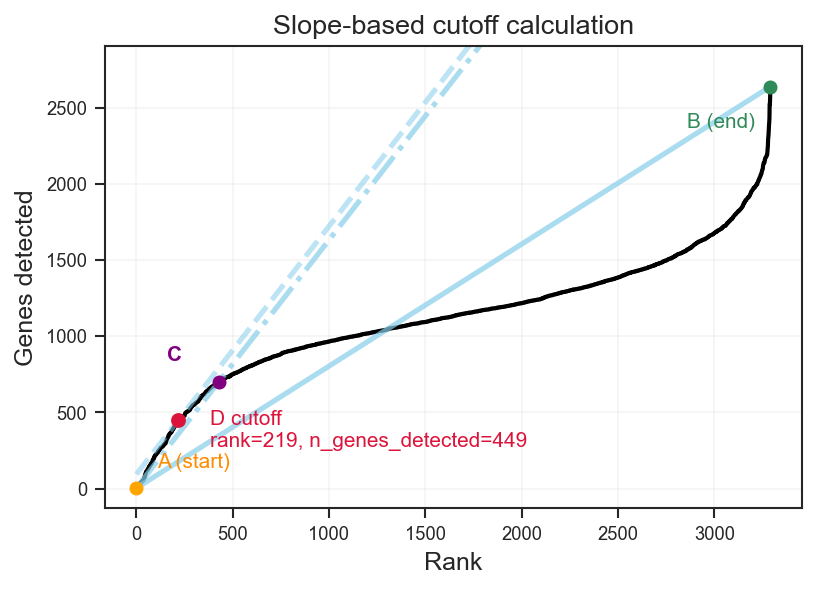

In [18]:
ax = sd.pl.plot_qc_cutoff_search(
    cutoffs=maxlfq_qc_output,
    figsize=(6, 4),
)
ax.set_title(ax.get_title(), fontsize=13)
ax.set_xlabel('Rank', fontsize=12)
ax.set_ylabel('Genes detected', fontsize=12)
plt.savefig(os.path.join(fig_dir, 'maxlfq_qc_cutoff_search.pdf'), dpi=300)

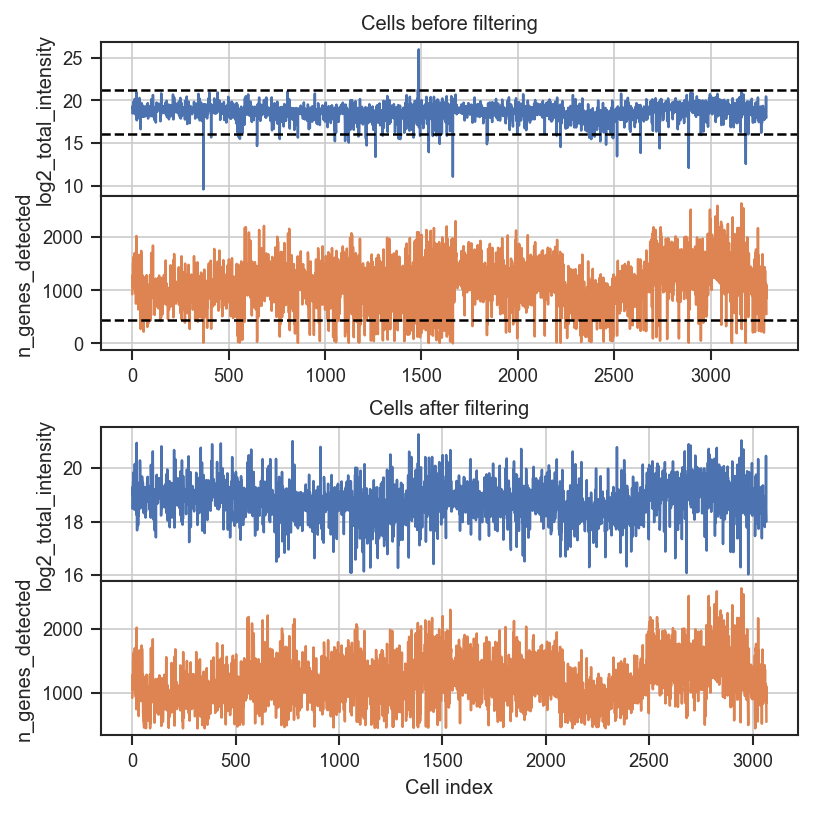

In [33]:
axes = sd.pl.plot_qc_filter_comparison(
    adata_1c_maxlfq_gene,
    cutoffs=maxlfq_qc_output,
    figsize=(6, 6),
)
axes['before_genes'].set_xlabel('')
plt.savefig(os.path.join(fig_dir, 'maxlfq_qc_filter_comparison.pdf'))

In [9]:
adata_1c_maxlfq_gene = adata_1c_maxlfq_gene[adata_1c_maxlfq_gene.obs.pass_qc_filter].copy()

In [10]:
sc.pp.filter_genes(adata_1c_maxlfq_gene, min_cells=3)

filtered out 1 genes that are detected in less than 3 cells


## Missingness and QC plots
Summarize missing values by batch variables and draw package-level QC plots.


In [11]:
missing_values_report_by_column_id = sd.qc.report_missing_values(adata_1c_maxlfq_gene, groupby='column_id')
missing_values_report_by_prepare_date = sd.qc.report_missing_values(adata_1c_maxlfq_gene, groupby='prepare_date')

missing_values_report_by_column_id.to_csv(os.path.join(results_dir, 'missing_values_report_by_column_id.tsv'), sep='\t', index=False)
missing_values_report_by_prepare_date.to_csv(os.path.join(results_dir, 'missing_values_report_by_prepare_date.tsv'), sep='\t', index=False)


In [12]:
missing_values_report_by_column_id

,group,n_cells,n_detected_features_total,detected_features_percent,mean_detected_features_per_cell,sd_detected_features_per_cell,detection_rate,missing_rate
0,Io01,1438,3861,89.811584,1319.154381,368.054381,0.306851,0.693149
1,Io02,898,2649,61.618981,991.483296,258.201623,0.230631,0.769369
2,Io03,732,3539,82.321470,1190.651639,296.401252,0.276960,0.723040


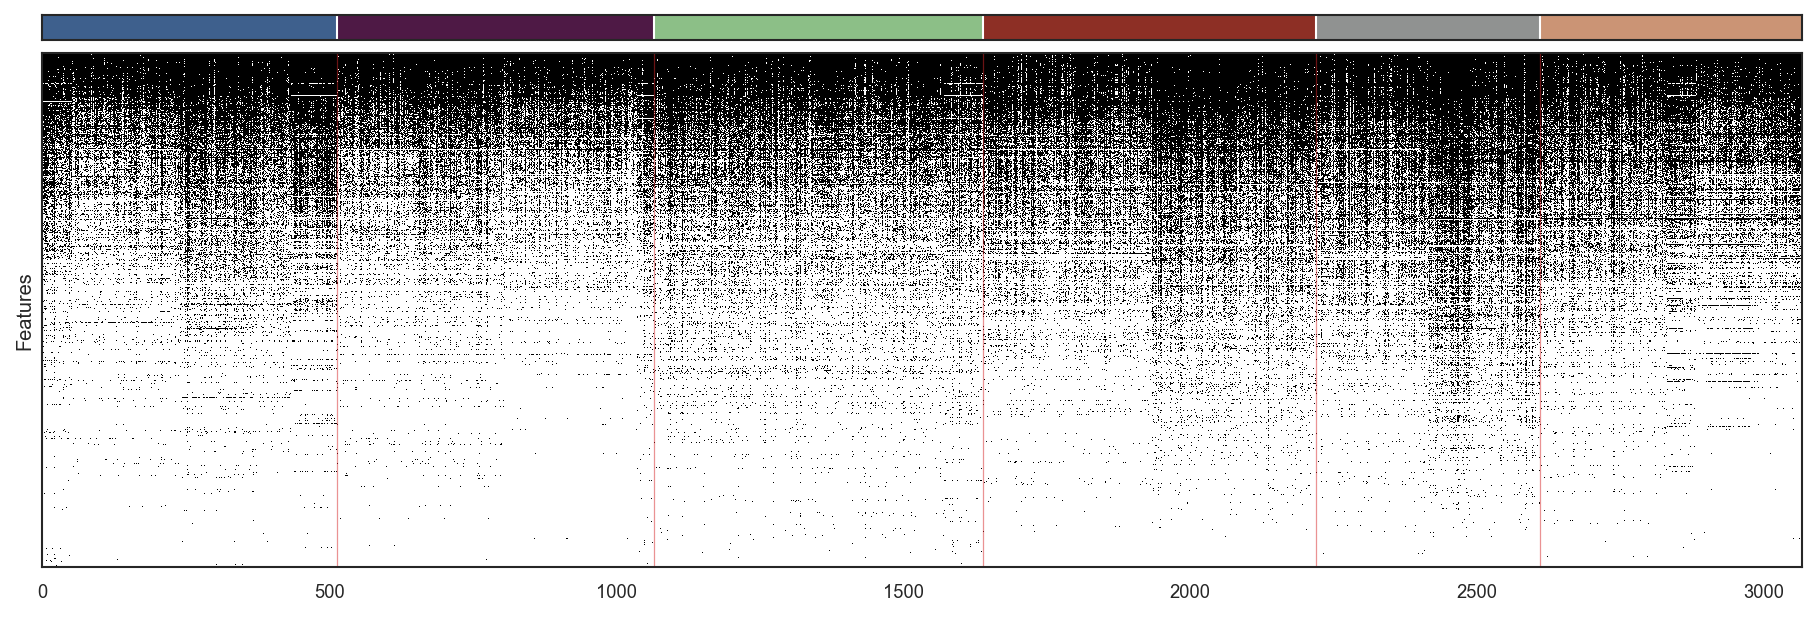

In [26]:
axes = sd.pl.plot_detection_heatmap_by_batch(
    adata_1c_maxlfq_gene,
    batch_col='prepare_date',
    max_cells=4000,
    max_features=4500,
    cluster_features=False,
    batch_palette=["#3e608d", "#4e1945", "#8cbf87", "#8d2f25", "#909291", "#cb9475"],
    figsize=(12, 4),
    batch_label=None
)
ax_batch = axes["batch"]
ax_heatmap = axes["heatmap"]
fig = ax_heatmap.figure

ax_batch.tick_params(bottom=False, top=False, left=False, right=False)
ax_heatmap.tick_params(bottom=False, top=False, left=False, right=False)

ax_batch.spines['left'].set_visible(False)
ax_batch.spines['bottom'].set_visible(False)
ax_batch.spines['right'].set_visible(False)
ax_batch.spines['top'].set_visible(False)

ax_heatmap.spines['top'].set_visible(True)
ax_heatmap.spines['right'].set_visible(True)

ax_heatmap.set_ylabel("Features", fontsize=14)
ax_heatmap.set_xticklabels("")

ax_batch.set_title("Detection heatmap by prepare_date", fontsize=15)

fig.savefig(os.path.join(fig_dir, 'maxlfq_detection_heatmap_by_prepare_date.png'), dpi=300, bbox_inches='tight')


Mean proteins detected per cell: 1192.6
Median proteins detected per cell: 1161.0
Percent of missing values: 72.26%


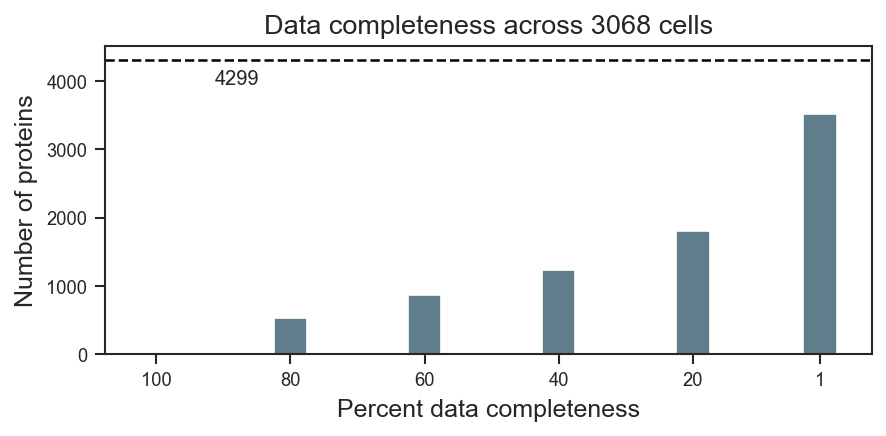

(<Figure size 900x450 with 1 Axes>,
 <Axes: title={'center': 'Data completeness across 3068 cells'}, xlabel='Percent data completeness', ylabel='Number of proteins'>)

In [14]:
fig, ax = plt.subplots(figsize=(6, 3))
sd.pl.plot_data_completeness(
    adata_1c_maxlfq_gene,
    color='#607D8B',
    ax=ax
)
fig.savefig(os.path.join(fig_dir, 'data_completeness.pdf'), dpi=300, bbox_inches='tight')


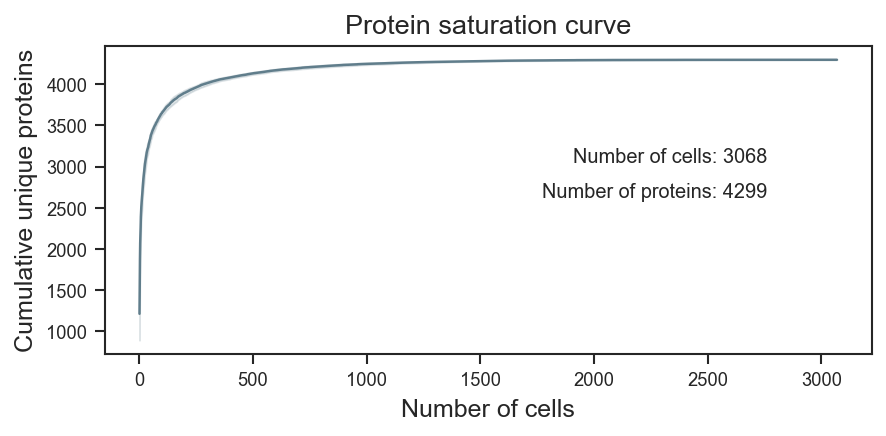

(<Figure size 900x450 with 1 Axes>,
 <Axes: title={'center': 'Protein saturation curve'}, xlabel='Number of cells', ylabel='Cumulative unique proteins'>)

In [17]:
fig, ax = plt.subplots(figsize=(6, 3))
sd.pl.plot_saturation_curve(
    adata_1c_maxlfq_gene,
    color='#607D8B',
    ax=ax
)
fig.savefig(os.path.join(fig_dir, 'maxlfq_saturation_curve.pdf'), dpi=300, bbox_inches='tight')


## Save QC-filtered matrix
Persist the filtered AnnData object for preprocessing.


In [16]:
adata_1c_maxlfq_gene.write_h5ad(results_dir + 'scp_MG_1c_maxlfq_gene_after_qc.h5ad', compression='gzip')

## Post-QC distribution diagnostics
Inspect intensity distributions, feature variability, and highly detected proteins.


In [22]:
# do a simple normalization for cv calculation
sc.pp.normalize_total(adata_1c_maxlfq_gene)

normalizing counts per cell
    finished (0:00:00)


In [23]:
feature_cv_result = calculate_feature_cv(adata_1c_maxlfq_gene, inplace=True)

In [24]:
feature_cv_result.cv.describe()

count    4299.000000
mean        0.977203
std         0.506935
min         0.090338
25%         0.710310
50%         0.857808
75%         1.080290
max         8.227592
Name: cv, dtype: float64

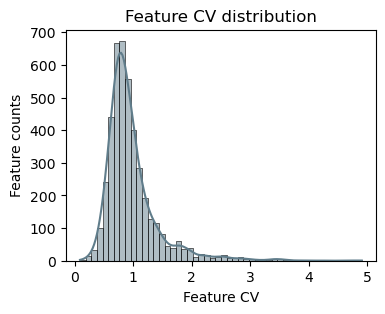

In [29]:
feature_cv_array = np.array(feature_cv_result[feature_cv_result.cv < 5].cv)
fig, ax = plt.subplots(figsize=(4, 3))
sns.histplot(
    feature_cv_array, 
    bins=50, 
    kde=True,
    color='#607D8B',
    ax=ax
)
ax.set_xticks(np.arange(0, 6, 1))
ax.set_xlabel('Feature CV')
ax.set_ylabel('Feature counts')
ax.set_title('Feature CV distribution')

plt.savefig(fig_dir + 'maxlfq_feature_cv_distribution.pdf', dpi=300, bbox_inches='tight')

### Take a look at the data distribution

In [19]:
adata_1c_maxlfq_gene = sc.read_h5ad(results_dir + 'scp_MG_1c_maxlfq_gene_after_qc.h5ad')

In [20]:
adata_1c_maxlfq_gene

AnnData object with n_obs × n_vars = 3068 × 4299
    obs: 'loading_date', 'prepare_date', 'column_id', 'LC_gradient', 'celltype', 'age', 'gender', 'brain_region', 'mass', 'plate_number', 'plate_location', 'Precursors_identified', 'Peptides_identified', 'ProteinGroups_identified', 'n_genes_detected', 'total_intensity', 'log2_total_intensity', 'pct_missing', 'pass_qc_filter'
    var: 'n_cells', 'n_cells_detected', 'pct_detected_cells', 'mean_intensity', 'median_intensity'

In [21]:
# get a nan matrix for downstream analysis
value_matrix = np.where(adata_1c_maxlfq_gene.X == 0, np.nan, adata_1c_maxlfq_gene.X)
log2_value_matrix = np.log2(value_matrix)

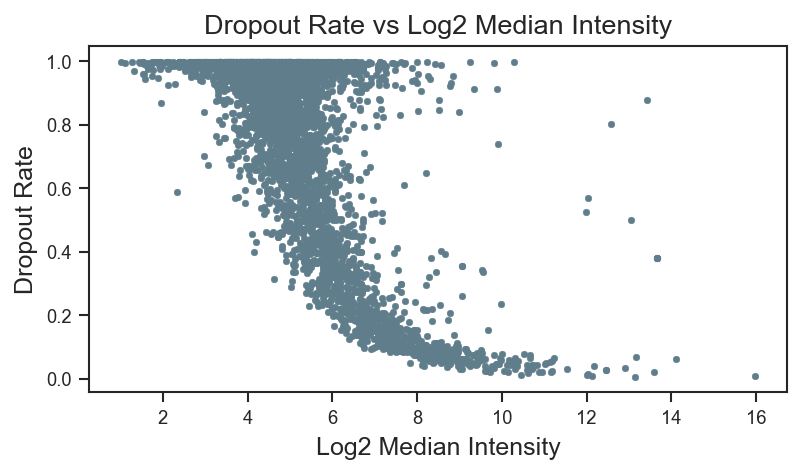

In [22]:
# plot dropout rate vs log2 median intensity
log2_intensity_median = np.log2(np.nanmedian(value_matrix, axis=0))
log2_intensity_mean = np.log2(np.nanmean(value_matrix, axis=0))

fig, ax = plt.subplots(figsize=(6, 3))

sns.scatterplot(
    x=log2_intensity_median,
    y=1 - adata_1c_maxlfq_gene.var['pct_detected_cells'] / 100,
    s=10,
    edgecolor=None,
    color='#607D8B',
    ax=ax
)
ax.set_xlabel('Log2 Median Intensity', fontsize=12)
ax.set_ylabel('Dropout Rate', fontsize=12)
ax.set_title('Dropout Rate vs Log2 Median Intensity', fontsize=13)

plt.savefig(fig_dir + 'maxlfq_dropout_vs_intensity.pdf', dpi=300, bbox_inches='tight')

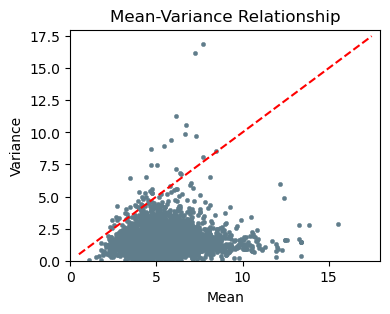

In [20]:
protein_mean = np.nanmean(log2_value_matrix, axis=0)
protein_var = np.nanvar(log2_value_matrix, axis=0)

plt.figure(figsize=(4, 3))
sns.scatterplot(x=protein_mean, y=protein_var, s=10, edgecolor=None, color='#607D8B')
plt.xlim(0, 18)
plt.ylim(0, 18)
plt.plot([0.5, 17.5], [0.5, 17.5], 'r--', color='red')  # Add a y=x reference line
plt.xlabel('Mean')
plt.ylabel('Variance')
plt.title('Mean-Variance Relationship')
plt.savefig(fig_dir + 'maxlfq_mean_variance_relationship.pdf', dpi=300, bbox_inches='tight')

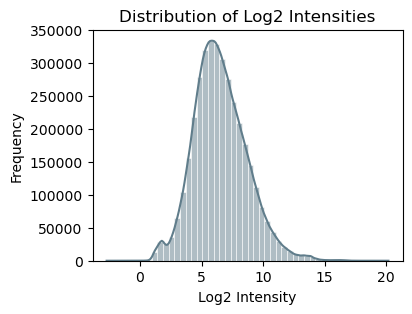

In [21]:
intensity_vector = log2_value_matrix.flatten()
intensity_vector = intensity_vector[~np.isnan(intensity_vector)]

plt.figure(figsize=(4, 3))
sns.histplot(intensity_vector, bins=50, kde=True, color='#607D8B', edgecolor='white')
plt.ylabel('Frequency')
plt.xlabel('Log2 Intensity')
plt.title('Distribution of Log2 Intensities')
plt.savefig(fig_dir + 'maxlfq_log2_intensity_distribution.pdf', dpi=300, bbox_inches='tight')

In [29]:
# get top 5 and top 15 less sparse proteins
top4_proteins = adata_1c_maxlfq_gene.var.n_cells_detected.sort_values(ascending=False).head(4).index
top4_proteins

Index(['Dsp', 'H4c1', 'Gapdh', 'Jup'], dtype='object', name='Gene')

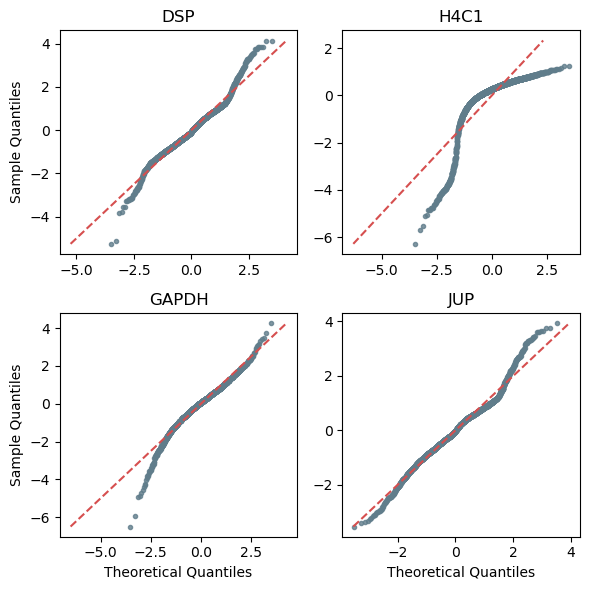

In [31]:
from scipy import stats

point_color = '#607D8B'
line_color = "#D64F4F" 

fig, axes = plt.subplots(2, 2, figsize=(6, 6))

axes = axes.flatten()

for i, protein in enumerate(top4_proteins):
    protein_values = log2_value_matrix[:, adata_1c_maxlfq_gene.var_names.get_loc(protein)]
    protein_values = protein_values[~np.isnan(protein_values)]
    protein_values = (protein_values - np.mean(protein_values)) / np.std(protein_values)

    stats.probplot(protein_values, dist="norm", plot=axes[i], fit=False)

    qq_obj = axes[i].get_lines()[0]
    qq_obj.set_markerfacecolor(point_color)
    qq_obj.set_markeredgecolor(point_color)
    qq_obj.set_color(point_color)
    qq_obj.set_markersize(3)
    qq_obj.set_alpha(0.8)

    min_val = min(protein_values.min(), stats.norm.ppf(0.01))
    max_val = max(protein_values.max(), stats.norm.ppf(0.99))
    axes[i].plot([min_val, max_val], [min_val, max_val],
                 color=line_color, linestyle='--', linewidth=1.5)

    axes[i].set_title(protein.upper(), fontsize=12)
    axes[i].set_xlabel('Theoretical Quantiles' if i in [2, 3] else '') 
    axes[i].set_ylabel('Sample Quantiles' if i in [0, 2] else None) 

plt.tight_layout()

plt.savefig(fig_dir + 'maxlfq_qq_plots_top4_proteins.pdf', dpi=300, bbox_inches='tight')
plt.show()

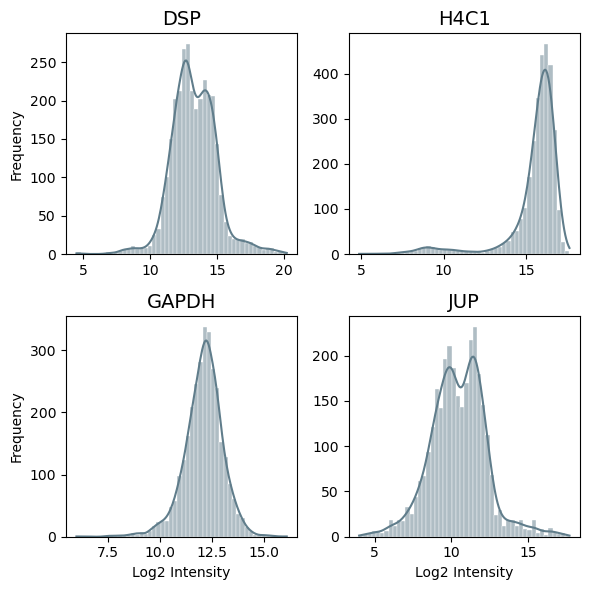

In [32]:
# Draw Histograms (Distribution plots) for the top4 less sparse proteins
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i, protein in enumerate(top4_proteins):
    protein_values = log2_value_matrix[:, adata_1c_maxlfq_gene.var_names.get_loc(protein)]
    protein_values = protein_values[~np.isnan(protein_values)]
    
    sns.histplot(protein_values, bins=50, kde=True, ax=axes[i], edgecolor='white', color='#607D8B')
    
    axes[i].set_title(protein.upper(), fontsize=14)
    axes[i].set_xlabel('Log2 Intensity' if i in [2, 3] else '')
    axes[i].set_ylabel('Frequency' if i in [0, 2] else '')

plt.tight_layout()
plt.savefig(fig_dir + 'maxlfq_histplot_top4_proteins.pdf', dpi=300, bbox_inches='tight')
plt.show()